In [1]:
import math

import matplotlib.pyplot as plt
import os

import keras
from keras import *
from keras.layers import *
from keras.activations import *
from keras.models import load_model, save_model
import tensorflow as tf
import numpy as np

import matplotlib.pyplot as plt

In [2]:
model_name = 'regression_simple_trained_model.h5'
nsamples = 1000
val_ratio = 0.2
test_ratio = 0.2
x_values = np.random.uniform(low=0, high=(2 * math.pi), size=nsamples)
y_values = np.sin(x_values)

In [3]:
val_split = int(val_ratio * nsamples)
test_split = int(val_split + (test_ratio * nsamples))
x_val, x_test, x_train = np.split(x_values, [val_split, test_split])
y_val, y_test, y_train = np.split(y_values, [val_split, test_split])

<function matplotlib.pyplot.show(close=None, block=None)>

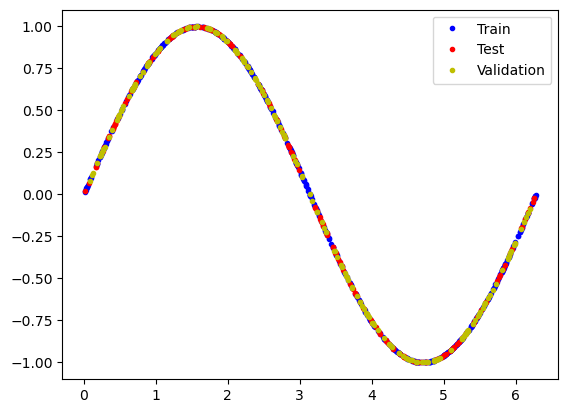

In [4]:
plt.plot(x_train, y_train, 'b.', label="Train")
plt.plot(x_test, y_test, 'r.', label="Test")
plt.plot(x_val, y_val, 'y.', label="Validation")
plt.legend()
plt.show

In [5]:
model = keras.Sequential()
model.add(layers.Dense(18, activation='relu', name='layer1', input_shape=(1,)))
model.add(layers.Dense(18, activation='relu', name='layer2'))
#model.add(layers.Dense(10, activation='relu', name='layer3'))
#model.add(layers.Dense(10, activation='relu', name='layer4'))
model.add(layers.Dense(1))

model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
layer1 (Dense)               (None, 18)                36        
_________________________________________________________________
layer2 (Dense)               (None, 18)                342       
_________________________________________________________________
dense (Dense)                (None, 1)                 19        
Total params: 397
Trainable params: 397
Non-trainable params: 0
_________________________________________________________________


Epoch 1/500
6/6 [==============================] - 1s 27ms/step - loss: 1.0404 - mae: 1.0404 - val_loss: 0.8898 - val_mae: 0.8898
Epoch 2/500
6/6 [==============================] - 0s 6ms/step - loss: 0.8815 - mae: 0.8815 - val_loss: 0.7879 - val_mae: 0.7879
Epoch 3/500
6/6 [==============================] - 0s 6ms/step - loss: 0.7726 - mae: 0.7726 - val_loss: 0.7115 - val_mae: 0.7115
Epoch 4/500
6/6 [==============================] - 0s 7ms/step - loss: 0.6874 - mae: 0.6874 - val_loss: 0.6341 - val_mae: 0.6341
Epoch 5/500
6/6 [==============================] - 0s 7ms/step - loss: 0.6128 - mae: 0.6128 - val_loss: 0.5796 - val_mae: 0.5796
Epoch 6/500
6/6 [==============================] - 0s 6ms/step - loss: 0.5678 - mae: 0.5678 - val_loss: 0.5460 - val_mae: 0.5460
Epoch 7/500
6/6 [==============================] - 0s 6ms/step - loss: 0.5388 - mae: 0.5388 - val_loss: 0.5268 - val_mae: 0.5268
Epoch 8/500
6/6 [==============================] - 0s 7ms/step - loss: 0.5229 - mae: 0.5229 - va

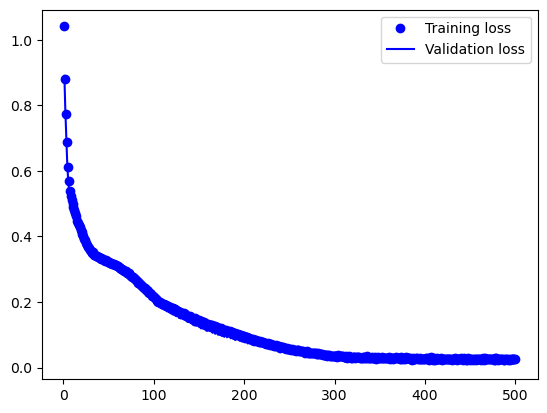

In [6]:
model.compile(optimizer='rmsprop', loss='mae', metrics=['mae'])
history = model.fit(x_train,
                    y_train,
                    epochs=500,
                    batch_size=100,
                    validation_data=(x_val, y_val))

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.legend()
plt.show()

In [7]:
print(x_test.shape)

(200,)


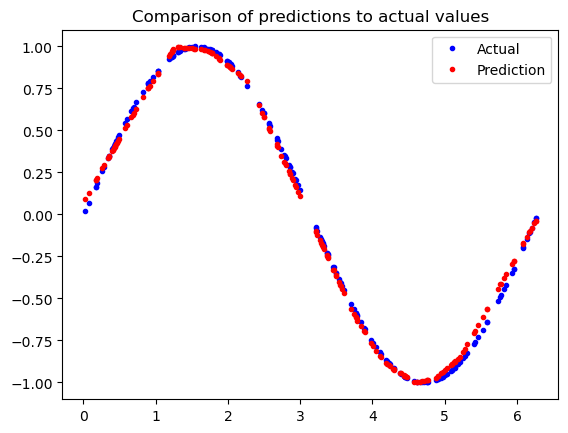

In [8]:
predictions = model.predict(x_test)

plt.clf()
plt.title("Comparison of predictions to actual values")
plt.plot(x_test, y_test, 'b.', label='Actual')
plt.plot(x_test, predictions, 'r.', label='Prediction')
plt.legend()
plt.show()

In [9]:
# test data to c file 
save_model(model, model_name)

In [10]:
from nnom import *


model = load_model(model_name)
evaluate_model(model=model, x_test=x_test, y_test=y_test)
generate_model(model, np.vstack((x_train, x_test)), name='regression_weights.h')

7/7 - 0s - loss: 0.0245 - mae: 0.0245
Test loss: 0.024503977969288826
Top 1: 0.024503977969288826


ValueError: all the input array dimensions for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 600 and the array at index 1 has size 200